In [1]:
import torch
from torch.utils.data import DataLoader
from gripper_data import GripperDataset, plot_images, compute_mean_images, load_images
import os
import sys
import numpy as np
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

### Dataset and Dataloader
Create dataset and load data

In [14]:
experiment = os.getenv("DATASET_EXPERIMENT") # experiment name
sessions = np.arange(1,21) # sessions to load
path = os.getenv("DATASET_PATH") # experiment path

# dataset = GripperDataset(experiment=experiment, sessions=sessions)
dataset = GripperDataset(abs_path=path, sessions=sessions, verbose=True)

dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

Loading data session 1
Loading data session 2
Loading data session 3
Loading data session 4
Loading data session 5
Loading data session 6
Loading data session 7
Loading data session 8
Loading data session 9
Loading data session 10
Loading data session 11
Loading data session 12
Loading data session 13
Loading data session 14
Loading data session 15
Loading data session 16
Loading data session 17
Loading data session 18
Loading data session 19
Loading data session 20


Inspect dataset and dataloader.

- Images -> RGB and with shape (Channels, Height, Width)

- States -> 5 values : x_norm, y_norm, z_norm, rotation, gripper_opening_norm

Number of samples in the dataset:  100000
Number of batches in the dataloader:  10000
Shape bottom image:  [3, 640, 480]
Shape top image:  [3, 720, 1280]
Shape state array:  [5]


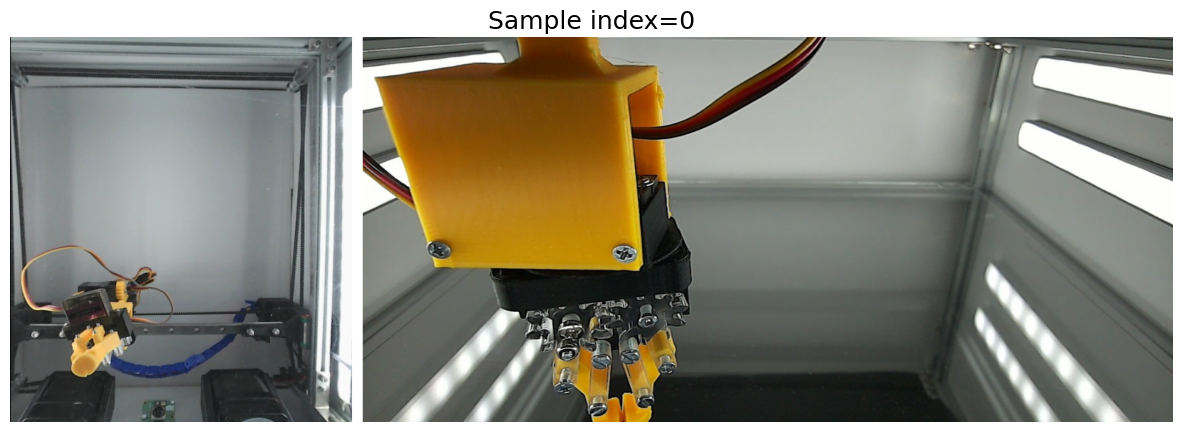

In [15]:
print("Number of samples in the dataset: ", dataset.__len__())
print("Number of batches in the dataloader: ", len(dataloader))
index = 0
bottom_img, top_img, state = dataset[index]
bottom_img_shape = bottom_img.shape
top_img_shape = top_img.shape
state_shape = state.shape

print("Shape bottom image: ", [*bottom_img_shape])
print("Shape top image: ", [*top_img_shape])
print("Shape state array: ", [*state_shape])

plot_images(bottom_img, top_img, title=f"Sample index={index}")

### Mean image
The average of a lot of images is an image of the clean environment, since that is the only static thing while the robot moves. However such average might be biased.

Loading existing mean images
Shape mean bottom image:  [3, 640, 480]
Shape mean top image:  [3, 720, 1280]


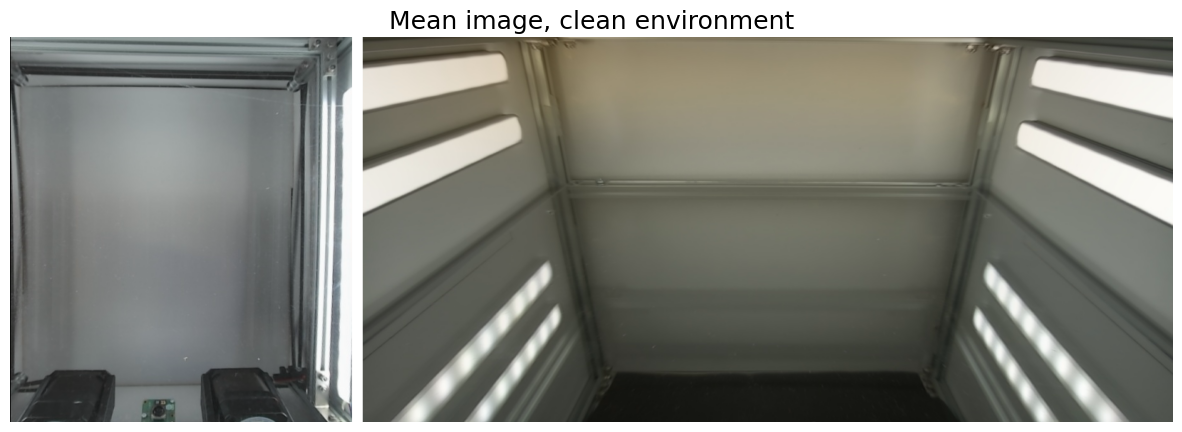

In [22]:
name = "_mean"
path = "clean_environment_images"
mean_bottom_file = os.path.join(path, f"bottom{name}.jpeg")
mean_top_file = os.path.join(path, f"top{name}.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(mean_bottom_file) and os.path.exists(mean_top_file):
    print("Loading existing mean images")
    mean_bottom, mean_top = load_images(path, name)

else:
    print("Calculating mean images")
    mean_bottom, mean_top = compute_mean_images(dataloader, path=path, name=name)

print("Shape mean bottom image: ", [*mean_bottom.shape])
print("Shape mean top image: ", [*mean_top.shape])
plot_images(mean_bottom, mean_top, title="Mean image, clean environment")

Load dataset with "custom" images type between the follwing folders' name:

- Bottom_image

- Images

- Top_masked_images

- Top_masks

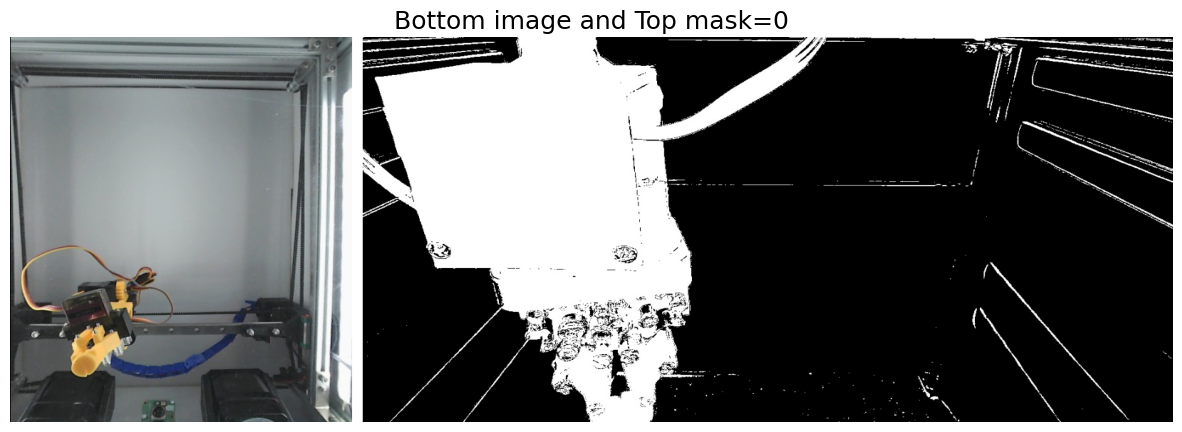

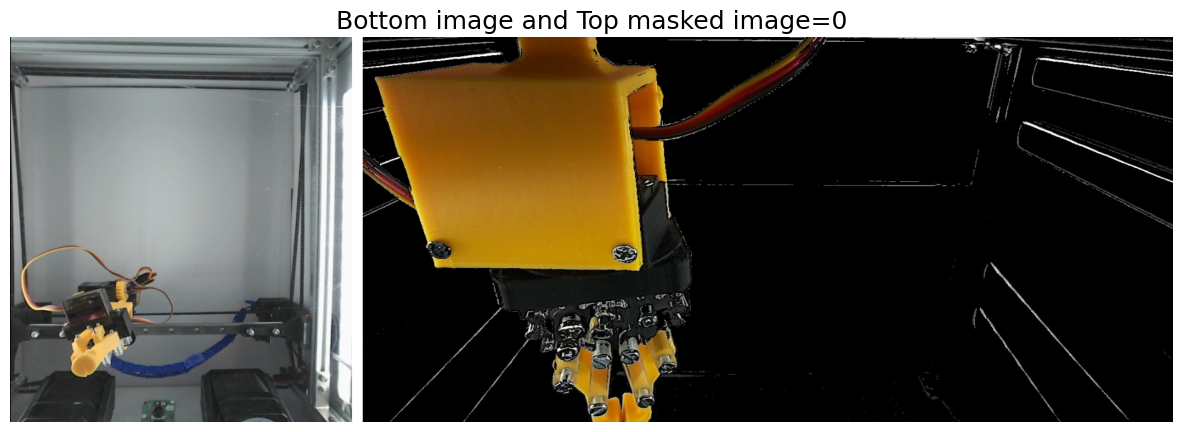

In [11]:
images_to_load = ["Bottom_images", "Top_masks", "Top_masked_images"]
# images_to_load = ["Bottom_images", "Images", "Top_masked_images"]

# dataset = GripperDataset(experiment=experiment, sessions=sessions)
dataset = GripperDataset(abs_path=path, sessions=sessions, images_to_load=images_to_load)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

bottom_img, top_mask, top_masked_img, state = dataset[index]
plot_images(bottom_img, top_mask, title=f"Bottom image and Top mask={index}")
plot_images(bottom_img, top_masked_img, title=f"Bottom image and Top masked image={index}")

Transformation for ResNet

- ToTensor()

-  Resize((224,224)) $\to$ break the aspect ratio

   Resize(256) $\to$ resize the shortest side and maintain the aspect ratio for the other

- Normalize() $\to$ normalization using mean and std of ImageNet dataset used for pretraining

In [ ]:
images_to_load = ["Images"]
images_to_load = ["Top_masked_images"]
dataset = GripperDataset(abs_path=path, sessions=sessions, images_to_load=images_to_load)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

mean = torch.zeros(3)
std = torch.zeros(3)
for img_batch, _ in dataloader:
    # mean and std per channel
    mean += img_batch.mean(dim=(2,3)).sum(dim=0)
    std += img_batch.std(dim=(2,3)).sum(dim=0)
mean /= len(dataset)
std /= len(dataset) 
print(f"Mean {images_to_load[0]}: ", mean.tolist())
print(f"Std {images_to_load[0]}: ", std.tolist())

In [13]:
mean = {}
std = {}
images_to_load_list = ["Images", "Top_masked_images"]
for img_type in images_to_load_list:
    images_to_load = [img_type]
    dataset = GripperDataset(abs_path=path, sessions=sessions, images_to_load=images_to_load)
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

    mean[img_type] = torch.zeros(3)
    std[img_type] = torch.zeros(3)
    for img_batch, _ in tqdm(dataloader, leave=False):
        # mean and std per channel
        mean[img_type] += img_batch.mean(dim=(2,3)).sum(dim=0)
        std[img_type] += img_batch.std(dim=(2,3)).sum(dim=0)
    mean[img_type] /= len(dataset)
    std[img_type] /= len(dataset)
    print(f"Mean {img_type}: ", mean[img_type].tolist())
    print(f"Std {img_type}: ", std[img_type].tolist())

Mean Images:  [0.4400623142719269, 0.439268559217453, 0.3936343789100647]
Std Images:  [0.23423318564891815, 0.22928224503993988, 0.24390383064746857]


Mean Top_masked_images:  [0.06538879126310349, 0.050828784704208374, 0.02297847904264927]
Std Top_masked_images:  [0.18178322911262512, 0.14339469373226166, 0.08912762999534607]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3597075045108795..9.51240348815918].


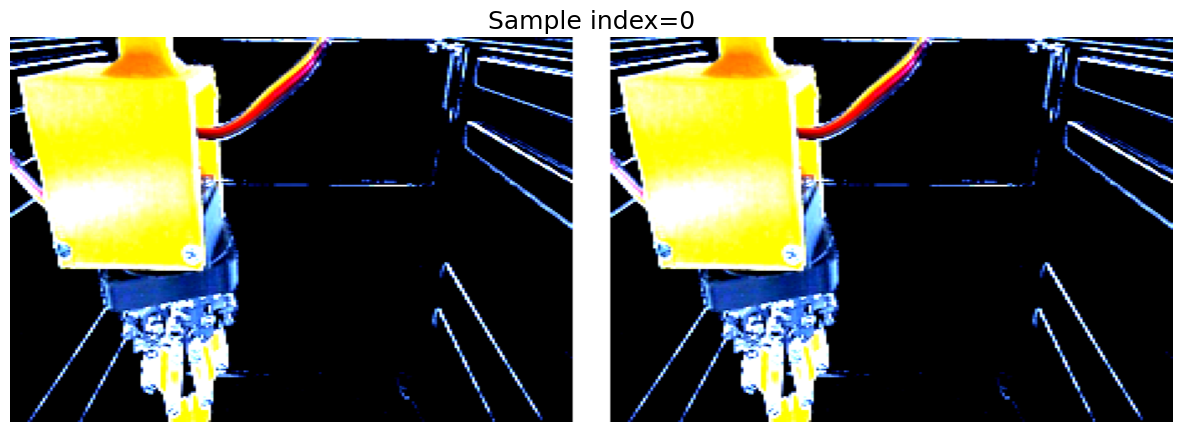

Shape bottom image:  [3, 224, 224]
Shape top image:  [3, 224, 224]
State (rotation normalized):  [0.2705     0.09764285 0.07222223 0.05       0.        ]


In [14]:
from torchvision import transforms 

images_to_load = ["Top_masked_images","Top_masked_images"]
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224,224)),
        # transforms.Resize(256), # resizes the shorter side of the image to 256 pixels while maintaining the aspect ratio
        # transforms.CenterCrop(224), # crops a 224×224 region from the center of the image 
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # mean and std of ImageNet dataset used for pretraining
        transforms.Normalize(mean=mean[images_to_load[1]].tolist(), std=std[images_to_load[1]].tolist()),
    ])
dataset = GripperDataset(abs_path=path, sessions=sessions, transform=preprocess, images_to_load=images_to_load)

index=0
bottom_img, top_img, state = dataset[index]
plot_images(bottom_img, top_img, title=f"Sample index={index}")
print("Shape bottom image: ", [*bottom_img.shape])
print("Shape top image: ", [*top_img.shape])
print("State (rotation normalized): ", state.numpy())

## Downscale images

Downscale images during loading for prototyping and use small input size.

Original images shape: (720, 1280)
Downscaled images shape: (720, 1280)


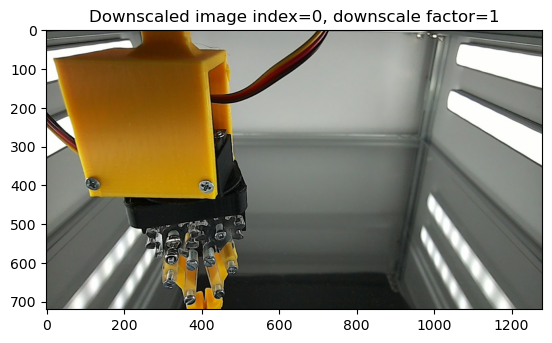

Original images shape: (720, 1280)
Downscaled images shape: (90, 160)


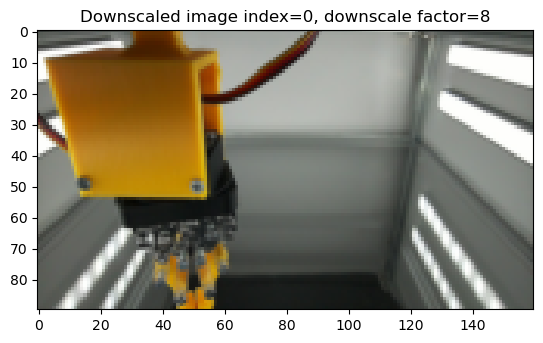

Original images shape: (720, 1280)
Downscaled images shape: (45, 80)


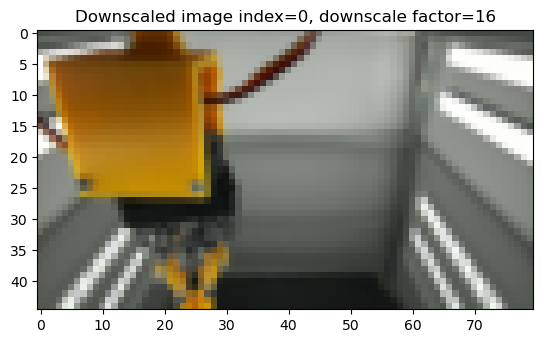

Original images shape: (720, 1280)
Downscaled images shape: (22, 40)


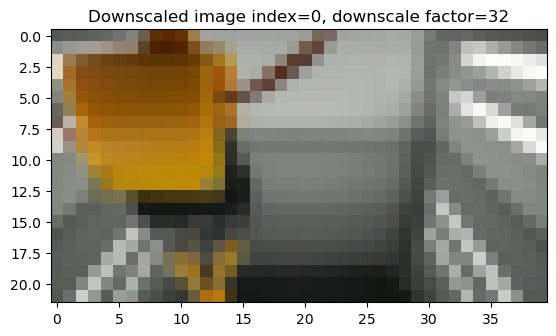

In [27]:
from torchvision import transforms
import matplotlib.pyplot as plt
from gripper_data import transpose_channels_last 

images_to_load = ["Images"]
downscale_factors = [1, 8, 16, 32]
_, height, width = top_img_shape

for downscale_factor in downscale_factors:
    resize_shape = (height//downscale_factor, width//downscale_factor)
    print(f"Original images shape: {(height, width)}")
    print(f"Downscaled images shape: {resize_shape}")

    preprocess = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(resize_shape),
        ])
    dataset = GripperDataset(abs_path=path, sessions=np.array([1]), transform=preprocess, images_to_load=images_to_load)

    index=0
    top_img, state = dataset[index]
    plt.figure()
    plt.imshow(transpose_channels_last(top_img))
    plt.title(f"Downscaled image index={index}, downscale factor={downscale_factor}")
    plt.show()